# **Ievads attēlu apstrādē**
## **Praktiskais darbs Nr. 3**
---

**Students:** Rihards Irbe  

**Studenta apliecības Nr.:** 251RDB259

**Saite uz programmēšanas kodu:** https://colab.research.google.com/drive/1Do7sVfJ_NfOMECtesiS6IrwwRmIniZex?authuser=2#scrollTo=Gz_9b9xw5L_C&line=12&uniqifier=1

---

## **Programmas kods ar izvadi**

Apstrādā: 1. Attēls - Impulsa troksnis...


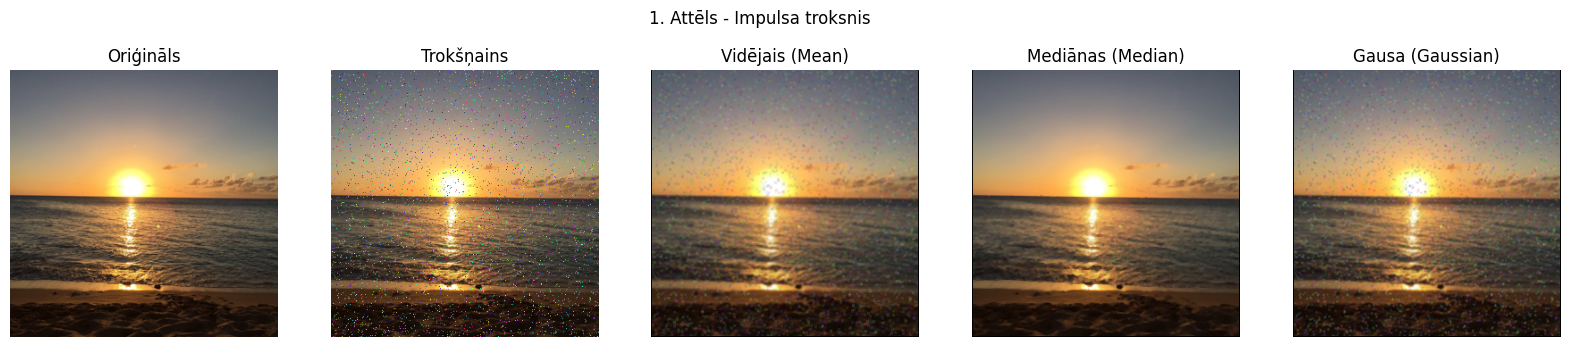

Apstrādā: 1. Attēls - Sāls/Piparu troksnis...


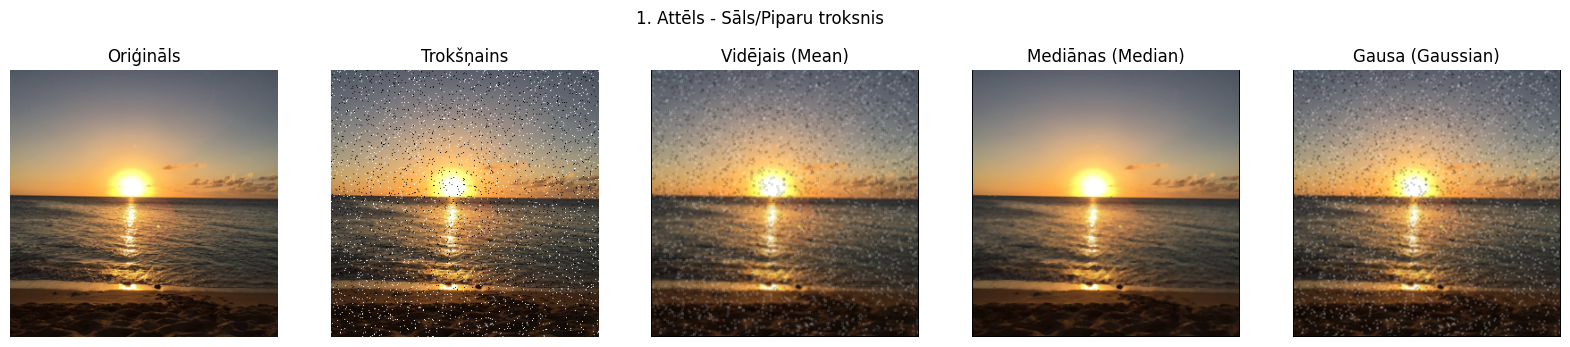

Apstrādā: 2. Attēls - Impulsa troksnis...


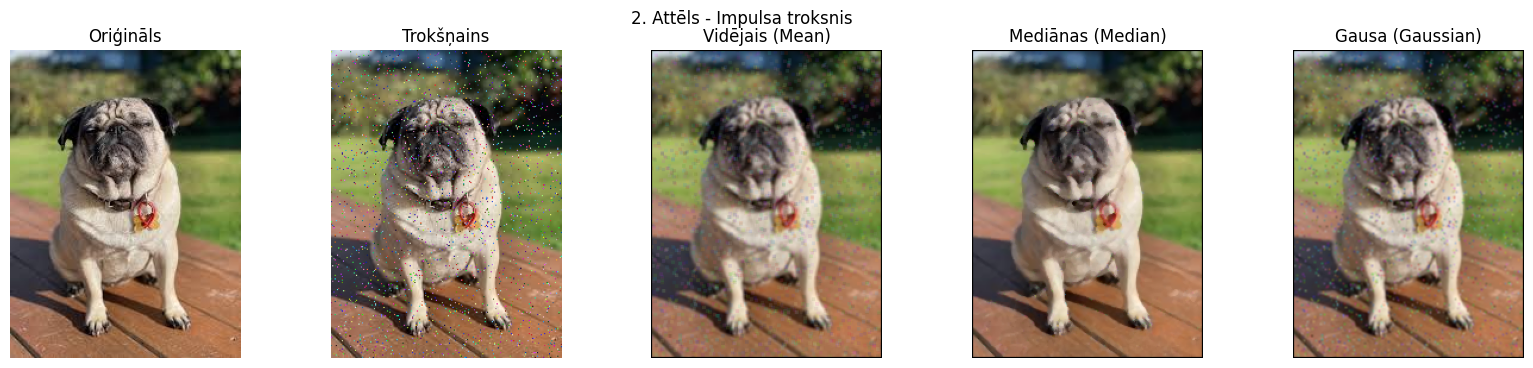

Apstrādā: 2. Attēls - Sāls/Piparu troksnis...


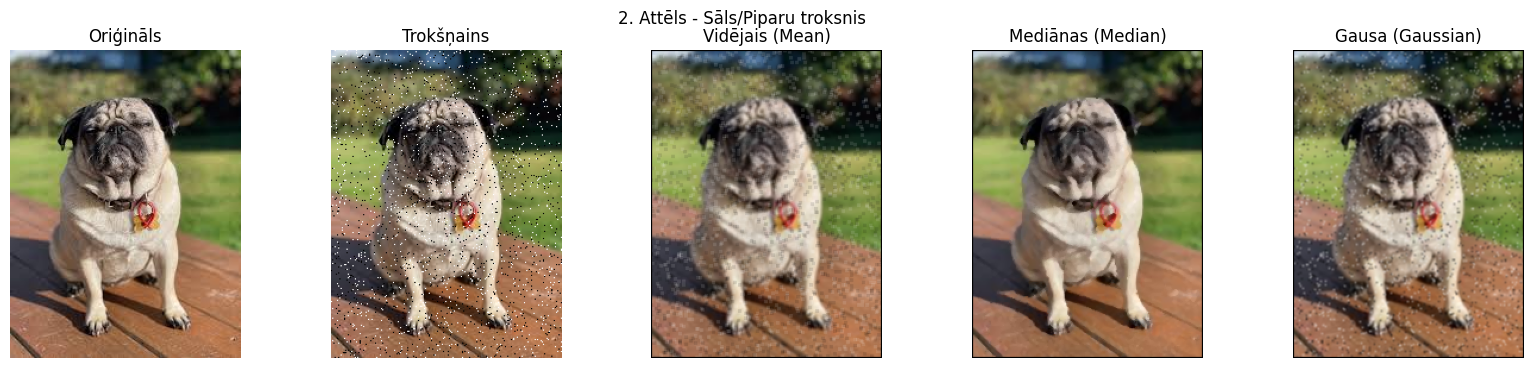

In [ ]:
from PIL import Image
import numpy as np
import requests
from io import BytesIO
import matplotlib.pyplot as plt

def load_image(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    img.thumbnail((300, 300))
    return img


def add_impulse_noise(image, intensity=0.05):

    width, height = image.size
    new_img = image.copy()
    pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            if np.random.random() < intensity:

                r = np.random.randint(0, 256)
                g = np.random.randint(0, 256)
                b = np.random.randint(0, 256)
                pixels[x, y] = (r, g, b)
    return new_img

def add_salt_pepper_noise(image, amount=0.05):

    width, height = image.size
    new_img = image.copy()
    pixels = new_img.load()

    for x in range(width):
        for y in range(height):
            random_val = np.random.random()
            if random_val < amount / 2:
                pixels[x, y] = (0, 0, 0)
            elif random_val < amount:
                pixels[x, y] = (255, 255, 255)
    return new_img


def apply_mean_filter(image):

    width, height = image.size
    pixels = image.load()
    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(1, width - 1):
        for y in range(1, height - 1):
            r_surrounding_sum, g_surrounding_sum, b_surrounding_sum = 0, 0, 0

            for i in range(-1, 2):
                for j in range(-1, 2):
                    r, g, b = pixels[x + i, y + j]
                    r_surrounding_sum += r
                    g_surrounding_sum += g
                    b_surrounding_sum += b

            new_pixels[x, y] = (r_surrounding_sum // 9, g_surrounding_sum // 9, b_surrounding_sum // 9)

    return new_img

def apply_median_filter(image):

    width, height = image.size
    pixels = image.load()
    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(1, width - 1):
        for y in range(1, height - 1):
            r_list, g_list, b_list = [], [], []

            for i in range(-1, 2):
                for j in range(-1, 2):
                    r, g, b = pixels[x + i, y + j]
                    r_list.append(r)
                    g_list.append(g)
                    b_list.append(b)

            r_list.sort()
            g_list.sort()
            b_list.sort()
            new_pixels[x, y] = (r_list[4], g_list[4], b_list[4])

    return new_img

def apply_gaussian_filter(image):
    kernel = [
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ]

    width, height = image.size
    pixels = image.load()
    new_img = Image.new("RGB", (width, height))
    new_pixels = new_img.load()

    for x in range(1, width - 1):
        for y in range(1, height - 1):
            r_weighted, g_weighted, b_weighted = 0, 0, 0

            for i in range(-1, 2):
                for j in range(-1, 2):
                    r, g, b = pixels[x + i, y + j]
                    weight = kernel[i + 1][j + 1]

                    r_weighted += r * weight
                    g_weighted += g * weight
                    b_weighted += b * weight

            new_pixels[x, y] = (r_weighted // 16, g_weighted // 16, b_weighted // 16)

    return new_img

def show_results(orig, noisy, mean, median, gauss, title):
    plt.figure(figsize=(20, 4))
    imgs = [orig, noisy, mean, median, gauss]
    names = ["Oriģināls", "Trokšņains", "Vidējais (Mean)", "Mediānas (Median)", "Gausa (Gaussian)"]

    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(imgs[i])
        plt.title(names[i])
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

url1 = "https://dynamic-media-cdn.tripadvisor.com/media/photo-o/17/e0/ce/85/sunset-beach.jpg?w=1200&h=1200&s=1"
url2 = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTMHpIPOQijz7ZFri38N6FH0mSpRD6ofUWgIg&s"

test_images = [
    ("1. Attēls - Impulsa troksnis", url1, "impulse"),
    ("1. Attēls - Sāls/Piparu troksnis", url1, "sp"),
    ("2. Attēls - Impulsa troksnis", url2, "impulse"),
    ("2. Attēls - Sāls/Piparu troksnis", url2, "sp")
]

for title, url, noise_type in test_images:
    print(f"Apstrādā: {title}...")
    img = load_image(url)

    if noise_type == "impulse":
        noisy = add_impulse_noise(img)
    else:
        noisy = add_salt_pepper_noise(img)

    mean_img = apply_mean_filter(noisy)
    median_img = apply_median_filter(noisy)
    gauss_img = apply_gaussian_filter(noisy)

    show_results(img, noisy, mean_img, median_img, gauss_img, title)

# **Secinājumi**

*1. Kurš filtrs vislabāk noņēma trokšņus?*

Mediānas filtrs vislabāk noņēma trokšņus, jo tas sakārto apkārtējo pikseļu vērtības un izvēlās vidējo, tādējāti tas pilnībā ignorē šīs pievienotās trokšņu vērtības.

*2. Kurš filtrs saglabāja visvairāk detaļu?*

Atkal mediānas filtrs, jo tas neaprēķina vidējo aritmētisko, tādēļ šīs asās malas/detaļas paliek, nevis šī pārēja starp pixeļiem ir graduāla, tādējādi veidojot miglotu attēlu.

*3. Kāda bija filtrēšanas efektivitāte katram tokšņa veidam?*

*Impulsa troksnis: Šie nejauši izvēlētie pikseļi ietekmē vidējo aprēķinu. Mediānas filtrs vislabāk tika ar tiem galā, redzu tikai kādus 2 rozā pikseļus, savukārt vidējais filtrs un gaussa filtrs atstāja šos trokšņus redzamus.

*Sāls/piparu troksnis: mediānas filtrs noņēma to pilnībā, savukārt vidējais filtrs un gaussa filtrs tikai izpludināja šos trokšņus, bet tos pilnībā neonāvca.

*4. Kur šādas metodes var tikt pielietotas praktiski?*

Fotogrāfijā: attēlu uzlabošana sliktas gaismas apstākļos
Drošības kamerās: video kvalitātes uzlabošanai
Rūpniecībā: kameras uzrauga produktu kvalitāti un filtrēšana palīdz precīzāk atklāt defektus
